<div style="background:linear-gradient(135deg,#0D1B2A 0%,#1565C0 100%);padding:36px 40px;border-radius:12px;margin-bottom:8px;">
  <div style="display:flex;align-items:center;gap:16px;">
    <span style="font-size:48px;">🛰️</span>
    <div>
      <p style="color:#ADE8F4;margin:0;font-size:13px;letter-spacing:3px;text-transform:uppercase;font-family:monospace;">Computer Vision for Remote Sensing · Bangladesh</p>
      <h1 style="color:#FFFFFF;margin:4px 0 0 0;font-size:28px;font-family:monospace;">Phase 1 · Raster CV Foundations</h1>
    </div>
  </div>
  <hr style="border-color:#1E88E5;margin:20px 0 16px 0;"/>
  <div style="display:flex;gap:32px;flex-wrap:wrap;">
    <span style="color:#90CAF9;font-family:monospace;font-size:13px;">📘 Lesson <b style="color:#FFF">L4 / 7</b></span>
    <span style="color:#90CAF9;font-family:monospace;font-size:13px;">⏱ Est. Time <b style="color:#FFF">3 hrs</b></span>
    <span style="color:#90CAF9;font-family:monospace;font-size:13px;">📍 Study Area <b style="color:#FFF">Sitakunda + EPZ</b></span>
    <span style="color:#90CAF9;font-family:monospace;font-size:13px;">📅 Date <b style="color:#FFF">____-__-__</b></span>
  </div>
</div>
<div style="background:#1565C022;border-left:5px solid #1565C0;padding:18px 24px;border-radius:0 8px 8px 0;">
  <h2 style="color:#1565C0;margin:0 0 8px 0;font-size:18px;">📖 L4 — Reprojection & Resampling</h2>
  <p style="margin:0;color:#1A2A3A;font-size:14px;">📝 <i>Add lesson description here — what is this lesson about?</i></p>
</div>

## 🎯 Objectives

By the end of this lesson you will be able to:

- ✅ _Objective 1_
- ✅ _Objective 2_
- ✅ _Objective 3_

---

## 🔑 Key Functions

| Function | Purpose |
|---|---|
| `function()` | description |


---
## ⚙️ Setup & Imports

In [3]:
# ── Cell 1: Imports & Paths ────────────────────────────────────────────────
import pathlib
import numpy as np
import matplotlib.pyplot as plt
import rasterio
import geopandas as gpd
from rasterio.warp import calculate_default_transform, reproject, Resampling
from rasterio.enums import Resampling as ResamplingEnum

# ── Band paths (your Landsat 9 data) ──────────────────────────────────────
BASE = pathlib.Path(r"H:/gis all/Band image cv roadmap geospatial/LC09_L2SP_137043_20260219_20260220_02_T1")

BANDS = {
    "B2_Blue" : BASE / "LC09_L2SP_137043_20260219_20260220_02_T1_SR_B2.TIF",
    "B3_Green": BASE / "LC09_L2SP_137043_20260219_20260220_02_T1_SR_B3.TIF",
    "B4_Red"  : BASE / "LC09_L2SP_137043_20260219_20260220_02_T1_SR_B4.TIF",
    "B5_NIR"  : BASE / "LC09_L2SP_137043_20260219_20260220_02_T1_SR_B5.TIF",
    "B6_SWIR1": BASE / "LC09_L2SP_137043_20260219_20260220_02_T1_SR_B6.TIF",
    "B7_SWIR2": BASE / "LC09_L2SP_137043_20260219_20260220_02_T1_SR_B7.TIF",
}

# ── Shapefile & output dirs ────────────────────────────────────────────────
SHP_PATH   = pathlib.Path(r"H:/gis all/test matuail land/shape file/Jatrabari.shp")
FIG_DIR    = pathlib.Path("../../outputs/figures/phase1")
REPROJ_DIR = pathlib.Path("../../outputs/reprojected")
RESAMP_DIR = pathlib.Path("../../outputs/resampled")

FIG_DIR.mkdir(parents=True, exist_ok=True)
REPROJ_DIR.mkdir(parents=True, exist_ok=True)
RESAMP_DIR.mkdir(parents=True, exist_ok=True)

# ── Verify files ───────────────────────────────────────────────────────────
print("File check:")
for name, path in BANDS.items():
    print(f"  {'✅' if path.exists() else '❌'} {name}: {path.name}")
print(f"  {'✅' if SHP_PATH.exists() else '❌'} Shapefile")

File check:
  ✅ B2_Blue: LC09_L2SP_137043_20260219_20260220_02_T1_SR_B2.TIF
  ✅ B3_Green: LC09_L2SP_137043_20260219_20260220_02_T1_SR_B3.TIF
  ✅ B4_Red: LC09_L2SP_137043_20260219_20260220_02_T1_SR_B4.TIF
  ✅ B5_NIR: LC09_L2SP_137043_20260219_20260220_02_T1_SR_B5.TIF
  ✅ B6_SWIR1: LC09_L2SP_137043_20260219_20260220_02_T1_SR_B6.TIF
  ✅ B7_SWIR2: LC09_L2SP_137043_20260219_20260220_02_T1_SR_B7.TIF
  ✅ Shapefile


---
## 1 · _Section Title_

> 📝 Add explanation here.

In [4]:
# ── Cell 2: Check Current CRS ─────────────────────────────────────────────
# Always check BEFORE doing anything — know what you are working with

with rasterio.open(BANDS["B4_Red"]) as src:
    print("=" * 50)
    print("ORIGINAL B4 Red — Spatial Properties")
    print("=" * 50)
    print(f"  CRS         : {src.crs}")
    print(f"  EPSG        : {src.crs.to_epsg()}")
    print(f"  Shape       : {src.height} rows x {src.width} cols")
    print(f"  Pixel size  : {src.res[0]:.2f}m x {src.res[1]:.2f}m")
    print(f"  Bands       : {src.count}")
    print(f"  Dtype       : {src.dtypes[0]}")
    print(f"  NoData      : {src.nodata}")
    print(f"  Bounds      : {src.bounds}")
    print(f"  Transform   :\n{src.transform}")

ORIGINAL B4 Red — Spatial Properties
  CRS         : EPSG:32646
  EPSG        : 32646
  Shape       : 7851 rows x 7711 cols
  Pixel size  : 30.00m x 30.00m
  Bands       : 1
  Dtype       : uint16
  NoData      : 0.0
  Bounds      : BoundingBox(left=154785.0, bottom=2599185.0, right=386115.0, top=2834715.0)
  Transform   :
| 30.00, 0.00, 154785.00|
| 0.00,-30.00, 2834715.00|
| 0.00, 0.00, 1.00|


In [5]:
# ── Cell 3: Reproject All 6 Bands to EPSG:32646 ───────────────────────────
# EPSG:32646 = UTM Zone 46N = Bangladesh standard CRS

TARGET_CRS = "EPSG:32646"
reproj_paths = {}

print(f"Reprojecting all bands to {TARGET_CRS}...\n")

for band_name, src_path in BANDS.items():
    out_path = REPROJ_DIR / f"{band_name}_32646.TIF"
    reproj_paths[band_name] = out_path

    with rasterio.open(src_path) as src:

        # Step 1: Calculate new transform and dimensions in target CRS
        transform, width, height = calculate_default_transform(
            src.crs,
            TARGET_CRS,
            src.width,
            src.height,
            *src.bounds
        )

        # Step 2: Copy profile and update only 4 things
        profile = src.profile.copy()
        profile.update(
            crs       = TARGET_CRS,
            transform = transform,
            width     = width,
            height    = height,
            compress  = "lzw"   # saves disk space
        )

        # Step 3: Reproject and write
        with rasterio.open(out_path, "w", **profile) as dst:
            reproject(
                source      = rasterio.band(src, 1),
                destination = rasterio.band(dst, 1),
                resampling  = Resampling.bilinear  # continuous SR data
            )

    print(f"  ✅ {band_name} → {out_path.name}")

# ── Verify one band after reprojection ────────────────────────────────────
print("\nAFTER reprojection (B4 Red):")
with rasterio.open(reproj_paths["B4_Red"]) as src:
    print(f"  CRS        : {src.crs}")
    print(f"  Shape      : {src.height} x {src.width}")
    print(f"  Pixel size : {src.res[0]:.2f}m x {src.res[1]:.2f}m")

Reprojecting all bands to EPSG:32646...

  ✅ B2_Blue → B2_Blue_32646.TIF
  ✅ B3_Green → B3_Green_32646.TIF
  ✅ B4_Red → B4_Red_32646.TIF
  ✅ B5_NIR → B5_NIR_32646.TIF
  ✅ B6_SWIR1 → B6_SWIR1_32646.TIF
  ✅ B7_SWIR2 → B7_SWIR2_32646.TIF

AFTER reprojection (B4 Red):
  CRS        : EPSG:32646
  Shape      : 7851 x 7711
  Pixel size : 30.00m x 30.00m


In [6]:
# ── Cell 4: Resampling ─────────────────────────────────────────────────────
# Change pixel size — useful when mixing Sentinel-2 (10m) with Landsat (30m)
# Here we demonstrate downsampling B4 from 30m to 60m (for demo purposes)

SCALE_FACTOR = 2   # 30m × 2 = 60m output
resamp_paths = {}

print(f"Resampling bands by factor {SCALE_FACTOR}...\n")

for band_name, src_path in reproj_paths.items():
    out_path = RESAMP_DIR / f"{band_name}_60m.TIF"
    resamp_paths[band_name] = out_path

    with rasterio.open(src_path) as src:
        new_height = src.height // SCALE_FACTOR
        new_width  = src.width  // SCALE_FACTOR

        # Rescale the transform
        new_transform = src.transform * src.transform.scale(
            src.width  / new_width,
            src.height / new_height
        )

        profile = src.profile.copy()
        profile.update(
            height    = new_height,
            width     = new_width,
            transform = new_transform,
            compress  = "lzw"
        )

        with rasterio.open(out_path, "w", **profile) as dst:
            data = src.read(
                out_shape = (src.count, new_height, new_width),
                resampling = ResamplingEnum.bilinear  # continuous data
                # use ResamplingEnum.nearest for class rasters (LULC masks)
            )
            dst.write(data)

    print(f"  ✅ {band_name} resampled → {out_path.name}")

print("\nB4 after resampling to 60m:")
with rasterio.open(resamp_paths["B4_Red"]) as src:
    print(f"  Shape      : {src.height} x {src.width}")
    print(f"  Pixel size : {src.res[0]:.2f}m x {src.res[1]:.2f}m")

Resampling bands by factor 2...

  ✅ B2_Blue resampled → B2_Blue_60m.TIF
  ✅ B3_Green resampled → B3_Green_60m.TIF
  ✅ B4_Red resampled → B4_Red_60m.TIF
  ✅ B5_NIR resampled → B5_NIR_60m.TIF
  ✅ B6_SWIR1 resampled → B6_SWIR1_60m.TIF
  ✅ B7_SWIR2 resampled → B7_SWIR2_60m.TIF

B4 after resampling to 60m:
  Shape      : 3925 x 3855
  Pixel size : 60.01m x 60.01m


In [8]:
# ── Cell 5: Verify Alignment Between Two Bands ────────────────────────────
# Before stacking bands or running ML — always verify they match exactly

def check_alignment(path1, path2, label1, label2):
    with rasterio.open(path1) as r1, rasterio.open(path2) as r2:
        print(f"\nAlignment check: {label1} vs {label2}")
        print(f"  CRS match       : {r1.crs == r2.crs} ({r1.crs})")
        print(f"  Shape match     : {r1.shape == r2.shape} ({r1.shape} vs {r2.shape})")
        print(f"  Transform match : {r1.transform == r2.transform}")
        print(f"  Pixel size match: {r1.res == r2.res} ({r1.res} vs {r2.res})")

        if r1.crs == r2.crs and r1.shape == r2.shape and r1.transform == r2.transform:
            print("  ✅ PERFECTLY ALIGNED — safe to stack and analyze")
        else:
            print("  ❌ NOT ALIGNED — do not stack these bands")

# Check reprojected bands align with each other
check_alignment(reproj_paths["B4_Red"], reproj_paths["B5_NIR"], "B4", "B5")
check_alignment(reproj_paths["B2_Blue"], reproj_paths["B7_SWIR2"], "B2", "B7")


Alignment check: B4 vs B5
  CRS match       : True (EPSG:32646)
  Shape match     : True ((7851, 7711) vs (7851, 7711))
  Transform match : True
  Pixel size match: True ((30.0, 30.0) vs (30.0, 30.0))
  ✅ PERFECTLY ALIGNED — safe to stack and analyze

Alignment check: B2 vs B7
  CRS match       : True (EPSG:32646)
  Shape match     : True ((7851, 7711) vs (7851, 7711))
  Transform match : True
  Pixel size match: True ((30.0, 30.0) vs (30.0, 30.0))
  ✅ PERFECTLY ALIGNED — safe to stack and analyze


In [10]:
# ── Cell 5: Verify Alignment Between Two Bands ────────────────────────────
# Before stacking bands or running ML — always verify they match exactly

def check_alignment(path1, path2, label1, label2):
    with rasterio.open(path1) as r1, rasterio.open(path2) as r2:
        print(f"\nAlignment check: {label1} vs {label2}")
        print(f"  CRS match       : {r1.crs == r2.crs} ({r1.crs})")
        print(f"  Shape match     : {r1.shape == r2.shape} ({r1.shape} vs {r2.shape})")
        print(f"  Transform match : {r1.transform == r2.transform}")
        print(f"  Pixel size match: {r1.res == r2.res} ({r1.res} vs {r2.res})")

        if r1.crs == r2.crs and r1.shape == r2.shape and r1.transform == r2.transform:
            print("  ✅ PERFECTLY ALIGNED — safe to stack and analyze")
        else:
            print("  ❌ NOT ALIGNED — do not stack these bands")

# Check reprojected bands align with each other
check_alignment(reproj_paths["B4_Red"], reproj_paths["B5_NIR"], "B4", "B5")
check_alignment(reproj_paths["B2_Blue"], reproj_paths["B7_SWIR2"], "B2", "B7")


Alignment check: B4 vs B5
  CRS match       : True (EPSG:32646)
  Shape match     : True ((7851, 7711) vs (7851, 7711))
  Transform match : True
  Pixel size match: True ((30.0, 30.0) vs (30.0, 30.0))
  ✅ PERFECTLY ALIGNED — safe to stack and analyze

Alignment check: B2 vs B7
  CRS match       : True (EPSG:32646)
  Shape match     : True ((7851, 7711) vs (7851, 7711))
  Transform match : True
  Pixel size match: True ((30.0, 30.0) vs (30.0, 30.0))
  ✅ PERFECTLY ALIGNED — safe to stack and analyze


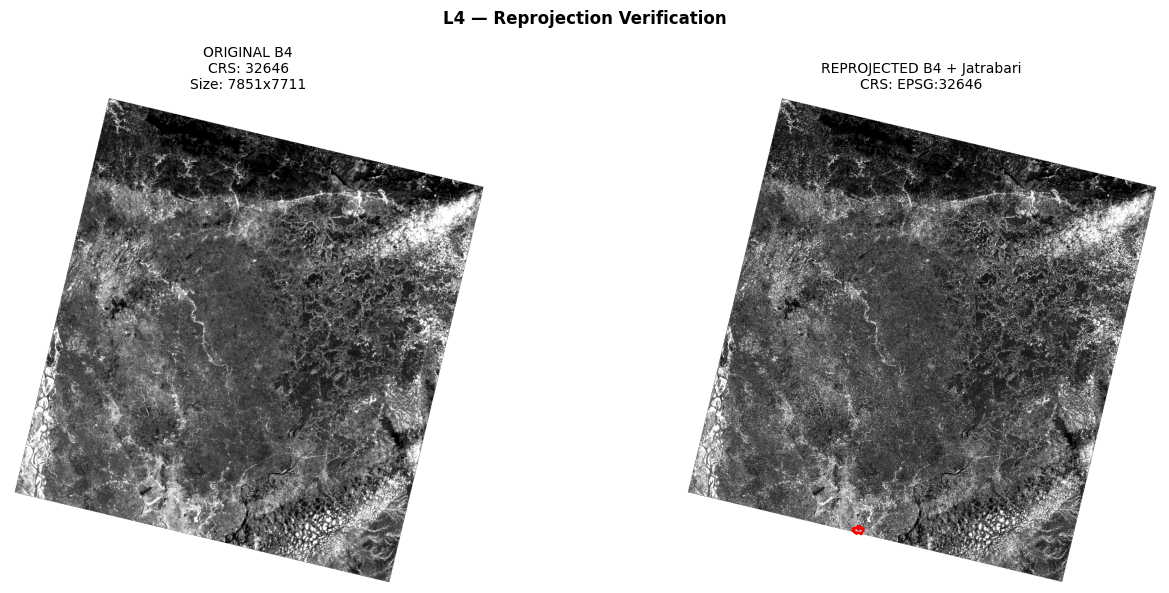

✅ Figure saved


In [12]:
# ── Cell 6: Visualization — downsampled for display ───────────────────────
from rasterio.plot import show

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ── Downsample factor — reads 1/8 of full resolution for display only ─────
DISPLAY_SCALE = 8

# ── Plot 1: Original B4 ───────────────────────────────────────────────────
with rasterio.open(BANDS["B4_Red"]) as src:
    h = src.height // DISPLAY_SCALE
    w = src.width  // DISPLAY_SCALE
    data = src.read(1, out_shape=(h, w)).astype(float)
    data[data == src.nodata] = np.nan

    axes[0].imshow(data, cmap="gray",
                   vmin=np.nanpercentile(data, 2),
                   vmax=np.nanpercentile(data, 98))
    axes[0].set_title(f"ORIGINAL B4\nCRS: {src.crs.to_epsg()}\nSize: {src.height}x{src.width}", fontsize=10)
    axes[0].axis("off")

# ── Plot 2: Reprojected B4 + Shapefile ────────────────────────────────────
with rasterio.open(reproj_paths["B4_Red"]) as src:
    h = src.height // DISPLAY_SCALE
    w = src.width  // DISPLAY_SCALE
    data = src.read(1, out_shape=(h, w)).astype(float)
    data[data == src.nodata] = np.nan

    axes[1].imshow(data, cmap="gray",
                   vmin=np.nanpercentile(data, 2),
                   vmax=np.nanpercentile(data, 98))

    # Overlay shapefile — transform coords to pixel space
    shp = gpd.read_file(SHP_PATH)
    if shp.crs.to_epsg() != 32646:
        shp = shp.to_crs("EPSG:32646")

    # Scale shapefile coords to downsampled image pixels
    scale_x = w / src.width
    scale_y = h / src.height
    transform_scaled = src.transform * src.transform.scale(
        src.width  / w,
        src.height / h
    )

    for geom in shp.geometry:
        from rasterio.transform import rowcol
        import shapely
        coords = np.array(geom.exterior.coords)
        # Convert geo coords to pixel coords
        rows, cols = rasterio.transform.rowcol(
            transform_scaled, coords[:, 0], coords[:, 1]
        )
        axes[1].plot(cols, rows, "r-", linewidth=1.5)

    axes[1].set_title(f"REPROJECTED B4 + Jatrabari\nCRS: EPSG:32646", fontsize=10)
    axes[1].axis("off")

plt.suptitle("L4 — Reprojection Verification", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "L4_reprojection_check.png", dpi=100, bbox_inches="tight")
plt.show()
print("✅ Figure saved")

In [ ]:
# ── Cell 7: Summary ───────────────────────────────────────────────────────
print("=" * 55)
print("L4 COMPLETE — Summary")
print("=" * 55)
print(f"\n  Target CRS      : EPSG:32646 (UTM Zone 46N)")
print(f"  Bands processed : {len(reproj_paths)}")
print(f"  Reprojected to  : {REPROJ_DIR}")
print(f"  Resampled to    : {RESAMP_DIR}")
print(f"\n  Resampling rules:")
print(f"    bilinear  → reflectance, LST, NDVI, continuous data")
print(f"    nearest   → LULC class labels, flood masks, categorical")
print(f"\n  reproj_paths dict carries forward to L5 and beyond.")
print(f"  Never use raw BANDS paths after this point.")
print("=" * 55)

In [13]:
# ── Cell 7: Summary ───────────────────────────────────────────────────────
print("=" * 55)
print("L4 COMPLETE — Summary")
print("=" * 55)
print(f"\n  Target CRS      : EPSG:32646 (UTM Zone 46N)")
print(f"  Bands processed : {len(reproj_paths)}")
print(f"  Reprojected to  : {REPROJ_DIR}")
print(f"  Resampled to    : {RESAMP_DIR}")
print(f"\n  Resampling rules:")
print(f"    bilinear  → reflectance, LST, NDVI, continuous data")
print(f"    nearest   → LULC class labels, flood masks, categorical")
print(f"\n  reproj_paths dict carries forward to L5 and beyond.")
print(f"  Never use raw BANDS paths after this point.")
print("=" * 55)


L4 COMPLETE — Summary

  Target CRS      : EPSG:32646 (UTM Zone 46N)
  Bands processed : 6
  Reprojected to  : ..\..\outputs\reprojected
  Resampled to    : ..\..\outputs\resampled

  Resampling rules:
    bilinear  → reflectance, LST, NDVI, continuous data
    nearest   → LULC class labels, flood masks, categorical

  reproj_paths dict carries forward to L5 and beyond.
  Never use raw BANDS paths after this point.


---
## 🏋️ Exercise

<div style="background:#FFF9C4;border-left:4px solid #F9A825;padding:14px 20px;border-radius:0 8px 8px 0;">
<b>Task:</b> Reprojection & Resampling — complete the exercise below.
</div>

In [ ]:
# ── YOUR CODE HERE ────────────────────────────────────────────────────────


---
## 📝 My Notes

> _Fill in after completing the exercise._

- Observation 1: `____`
- Observation 2: `____`
- Anything unexpected: `____`


---
<div style="background:linear-gradient(135deg,#0D1B2A 0%,#1565C0 100%);padding:24px 32px;border-radius:10px;">
  <h2 style="color:#FFFFFF;margin:0 0 12px 0;font-size:18px;">✅ Key Takeaways — L4</h2>
  <ul style="color:#C8E6C9;font-size:14px;line-height:2.2;margin:0;">
    <li>_Takeaway 1_</li>
    <li>_Takeaway 2_</li>
    <li>_Takeaway 3_</li>
  </ul>
</div>

---
<div style="display:flex;justify-content:space-between;padding:10px 0;font-size:13px;color:#9E9E9E;">
  <span>← Previous: <a href="L3_prev.ipynb">L3</a></span>
  <b style="color:#1565C0;">Phase 1 · L4 of 7</b>
  <span><a href="L5_next.ipynb" style="color:#1565C0;">Next: L5 →</a></span>
</div>